In [1]:
import os
from torchvision import io, utils
from pycocotools.coco import COCO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from pycocotools.cocoeval import COCOeval
from torchvision.datasets import CocoDetection
from torchvision.transforms import ToPILImage
import torch
from torchvision.transforms.functional import to_tensor
import pytorch_lightning as pl
import json
import pandas as pd

import lightly_train

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# PARAMETERS
MODEL_TYPE = "dinov3"
VERSION = "1_puro"
CHECKPOINT = "./output_dinov3/exported_models/exported_best.pt"
EVALUATION_RESULTS_FOLDER = "./evaluation_results"


# Caminhos do dataset
ROOT_DIR = "../../SVRDD_COCO"
TRAIN_DIRECTORY = os.path.join(ROOT_DIR, "train")
VAL_DIRECTORY = os.path.join(ROOT_DIR, "valid")
TEST_DIRECTORY = os.path.join(ROOT_DIR, "test")
ANNOTATION_FILE_NAME = "_annotations.coco.json"
DETECTIONS_PATH = "detections.json"
CLASSES = {
    0: "longitudinal crack",
    1: "transverse crack",
    2: "alligator crack",
    3: "pothole",
    4: "manhole cover",
    5: "longitudinal patch",
    6: "transverse patch",
}

In [ ]:
def count_classes(coco_gt):
    # --- Contagem de instâncias ---
    cat_ids = coco_gt.getCatIds()
    cats = [coco_gt.loadCats([i])[0]["name"] for i in cat_ids]
    area_labels = ["small", "medium", "large"]

    counts_dict = {cat: {"small":0, "medium":0, "large":0} for cat in cats}
    ann_ids = coco_gt.getAnnIds()
    anns = coco_gt.loadAnns(ann_ids)

    for ann in anns:
        cat_name = coco_gt.loadCats([ann["category_id"]])[0]["name"]
        area = ann["area"]
        if area < 32**2:
            counts_dict[cat_name]["small"] += 1
        elif area < 96**2:
            counts_dict[cat_name]["medium"] += 1
        else:
            counts_dict[cat_name]["large"] += 1
    return cats, counts_dict


def evaluate_coco(dataset_dir, json_detection_path, excel_path="coco_results.xlsx"):

    GT_ANN_FILE = os.path.join(dataset_dir, ANNOTATION_FILE_NAME)

    # carregar ground truth
    coco_gt = COCO(GT_ANN_FILE)

    # carregar detecções
    coco_dt = coco_gt.loadRes(json_detection_path)

    # rodar avaliação
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    # métricas por classe
    cats, counts_dict = count_classes(coco_gt)

    # Converter para DataFrame
    df_counts = pd.DataFrame(counts_dict).T
    df_counts["total"] = df_counts.sum(axis=1)
    df_counts = df_counts[["total", "small", "medium", "large"]]
    print("\n=== Contagem de instâncias por classe e tamanho ===")
    print(df_counts)

    # --- Tabelas de métricas ---
    precisions = coco_eval.eval['precision']  # [TxRxKxAxM]
    iou_thrs = coco_eval.params.iouThrs
    iou50_idx = np.where(iou_thrs == 0.5)[0][0]
    maxDets_idx = 2  # normalmente corresponde a 100 maxDets
    area_labels_full = ["all", "small", "medium", "large"]
    metrics_tables = {}
    
    for a_idx, area in enumerate(area_labels_full):
        data = []
        for idx, cat in enumerate(cats):
            # mAP 0.50:0.95
            precision_all = precisions[:, :, idx, a_idx, maxDets_idx]
            precision_all = precision_all[precision_all > -1]
            mAP = np.mean(precision_all) if precision_all.size > 0 else np.nan

            # mAP50
            precision50 = precisions[iou50_idx, :, idx, a_idx, maxDets_idx]
            precision50 = precision50[precision50 > -1]
            mAP50 = np.mean(precision50) if precision50.size > 0 else np.nan

            # quantidade
            if area == "all":
                qty = df_counts.loc[cat, "total"]
            else:
                qty = df_counts.loc[cat, area]

            data.append([qty, mAP50, mAP])

        df_metrics = pd.DataFrame(data, columns=["Quantidade", "mAP50", "mAP50:0.95"], index=cats)
        metrics_tables[area] = df_metrics
        print(f"\n=== Métricas para tamanho '{area}' ===")
        print(df_metrics.round(3))

    # --- Exportar tudo para Excel ---
    with pd.ExcelWriter(excel_path) as writer:
        df_counts.round(3).to_excel(writer, sheet_name="counts")
        for area, df in metrics_tables.items():
            df.round(3).to_excel(writer, sheet_name=area)

    print(f"\n📁 Arquivo Excel exportado com sucesso para: {excel_path}")
    return coco_eval

def get_one_example_prediction(image_id: int, results: list):
    pred_box = []
    pred_label = []
    pred_score = []
    for i in range(len(results)):
        # Pegar todas as boxes , labels e scores do resultado que tiver image_id == x
        if results[i]["image_id"] == image_id + 1:
            pred_box.append(results[i]["bbox"])
            pred_label.append(results[i]["category_id"])
            pred_score.append(results[i]["score"])
        elif results[i]["image_id"] > image_id + 1:
            break

    pred_box = torch.tensor(pred_box)
    pred_label = torch.tensor(pred_label)
    pred_score = torch.tensor(pred_score)
    return pred_box, pred_label, pred_score

def coco_load_image(img_info: dict, dataset_dir: str):
    # Getting image tensor
    img_path = os.path.join(dataset_dir, img_info["file_name"])
    image = Image.open(img_path).convert("RGB")
    img_tensor = to_tensor(image).to(device)
    return image, img_tensor

def get_image_and_target(image_id: int, dataset_dir: str):
    
    # Getting dataset on coco format
    coco = COCO(os.path.join(dataset_dir, ANNOTATION_FILE_NAME))

    # Getting image tensor
    coco_img_id = coco.getImgIds()[image_id]
    img_info = coco.loadImgs(coco_img_id)[0]
    _, img_tensor = coco_load_image(img_info, dataset_dir)

    # Getting annotation target
    ann_ids = coco.getAnnIds(imgIds=coco_img_id)
    anns = coco.loadAnns(ann_ids)
    target = {
        "boxes": torch.tensor([ann["bbox"] for ann in anns], dtype=torch.float32).to(device),
        "labels": torch.tensor([ann["category_id"] for ann in anns], dtype=torch.int64).to(device),
    }
    target["boxes"][:, 2] = target["boxes"][:, 0] + target["boxes"][:, 2]
    target["boxes"][:, 3] = target["boxes"][:, 1] + target["boxes"][:, 3]
    return img_tensor, target


In [3]:
import json
import os
import numpy as np
from pycocotools.coco import COCO

def iou_bbox(b1, b2):
    # b = [x,y,w,h]
    x1, y1, w1, h1 = b1
    x2, y2, w2, h2 = b2
    xa = max(x1, x2)
    ya = max(y1, y2)
    xb = min(x1 + w1, x2 + w2)
    yb = min(y1 + h1, y2 + h2)
    iw = max(0.0, xb - xa)
    ih = max(0.0, yb - ya)
    inter = iw * ih
    union = w1*h1 + w2*h2 - inter
    return 0.0 if union <= 0 else inter/union

def precision_recall_at_threshold(coco_gt, detections, iou=0.5, score_th=0.5):
    """
    detections: lista de dicts (json COCO) com keys: image_id, bbox, score, category_id
    coco_gt: objeto COCO carregado
    retorna: precision, recall, f1, TP, FP, FN
    """
    # filtra por score
    dets = [d for d in detections if d.get("score", 1.0) >= score_th]

    # agrupa por image_id
    dets_by_img = {}
    for d in dets:
        dets_by_img.setdefault(d["image_id"], []).append(d)

    # prepeara GT por imagem (cada GT é dict com bbox)
    gt_by_img = {}
    img_ids = coco_gt.getImgIds()
    for img_id in img_ids:
        ann_ids = coco_gt.getAnnIds(imgIds=[img_id], iscrowd=None)
        anns = coco_gt.loadAnns(ann_ids)
        gt_by_img[img_id] = anns  # cada ann tem 'bbox', 'category_id', 'id', etc.

    TP = 0
    FP = 0
    FN = 0

    # para cada imagem, faz matching greedy por score entre dets e GTs (mesma categoria)
    for img_id, gts in gt_by_img.items():
        gt_matched = [False] * len(gts)

        img_dets = dets_by_img.get(img_id, [])
        # ordenar por score desc (já filtradas)
        img_dets = sorted(img_dets, key=lambda x: x.get("score", 0), reverse=True)

        for det in img_dets:
            best_iou = 0.0
            best_gt_idx = -1
            for gi, gt in enumerate(gts):
                if gt_matched[gi]:
                    continue
                # opcional: exigir mesmo category_id
                if det.get("category_id") != gt.get("category_id"):
                    continue
                i = iou_bbox(det["bbox"], gt["bbox"])
                if i > best_iou:
                    best_iou = i
                    best_gt_idx = gi
            if best_iou >= iou and best_gt_idx >= 0:
                TP += 1
                gt_matched[best_gt_idx] = True
            else:
                FP += 1

        # GTs não casados são FN
        FN += sum(1 for m in gt_matched if not m)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return precision, recall, f1, TP, FP, FN

def best_f1_threshold(dataset_dir, json_detection_path, iou=0.5, n_thresholds=50):
    GT_ANN_FILE = os.path.join(dataset_dir, ANNOTATION_FILE_NAME)  # ajuste se tiver outro nome
    coco_gt = COCO(GT_ANN_FILE)

    with open(json_detection_path, "r") as f:
        detections = json.load(f)

    thresholds = np.linspace(0.0, 1.0, n_thresholds)
    best = (0.0, 0.0, 0.0, 0, 0, 0)  # th, f1, prec, rec, TP, FP, FN
    best_th = 0.0
    for th in thresholds:
        prec, rec, f1, TP, FP, FN = precision_recall_at_threshold(coco_gt, detections, iou=iou, score_th=th)
        if f1 > best[1]:
            best = (th, f1, prec, rec, TP, FP, FN)
            
    # retorna threshold ótimo e métricas
    return {"best_threshold": best[0],
            "best_f1": best[1],
            "precision": best[2],
            "recall": best[3],
            "TP": best[4],
            "FP": best[5],
            "FN": best[6]}


In [4]:
EVALUATE_DIRECTORY = TEST_DIRECTORY
json_detection_file = f'{os.path.basename(EVALUATE_DIRECTORY)}_{MODEL_TYPE}_{VERSION}_{DETECTIONS_PATH}'
json_detection_path = os.path.join(EVALUATION_RESULTS_FOLDER, json_detection_file)
res = best_f1_threshold(EVALUATE_DIRECTORY, json_detection_path)
res 

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


{'best_threshold': np.float64(0.6122448979591836),
 'best_f1': 0.755423224159932,
 'precision': 0.8338028169014085,
 'recall': 0.6905132192846034,
 'TP': 1776,
 'FP': 354,
 'FN': 796}

# DINOv3

In [26]:
EVALUATE_DIRECTORY = TRAIN_DIRECTORY
REEVALUATE = False

os.makedirs(EVALUATION_RESULTS_FOLDER, exist_ok=True)
json_detection_file = f'{os.path.basename(EVALUATE_DIRECTORY)}_{MODEL_TYPE}_{VERSION}_{DETECTIONS_PATH}'
json_detection_path = os.path.join(EVALUATION_RESULTS_FOLDER, json_detection_file) 
if REEVALUATE or not os.path.isfile(json_detection_path):
    
    ###################################################
    # Instantiating model                             #
    ###################################################
    
    model = lightly_train.load_model(CHECKPOINT).to(device)
    
    ###################################################
    
    EVALUATE_DATASET = COCO(os.path.join(EVALUATE_DIRECTORY, ANNOTATION_FILE_NAME))
    image_ids = EVALUATE_DATASET.getImgIds()
    
    # Model Inference
    all_preds = []
    for img_id in tqdm(image_ids, desc="Predicting on Dataset..."):
    
        img_info = EVALUATE_DATASET.loadImgs(img_id)[0]
        image, img_tensor = coco_load_image(img_info, EVALUATE_DIRECTORY)

        ###################################################
        # Model Predicting                                #
        ###################################################
        
        #img = ToPILImage()(img_tensor)
        #print("img_tensor =", img_tensor)
        labels, boxes, scores = model.predict(image).values()

        ###################################################
        # Outputs Handling (box, label, score COCO format)#
        ###################################################
        
        boxes = boxes.cpu().numpy()
        scores = scores.cpu().numpy()
        labels = labels.cpu().numpy()

        # converter boxes para formato COCO: [x, y, w, h]
        boxes[:, 2] = boxes[:, 2] - boxes[:, 0]
        boxes[:, 3] = boxes[:, 3] - boxes[:, 1]
    
        ###################################################
        
        # montar cada previsão
        for box, score, label in zip(boxes, scores, labels):
            all_preds.append({
                "image_id": img_id,
                "category_id": int(label),
                "bbox": box.tolist(),
                "score": float(score)
            })
    with open(json_detection_path, "w") as f:
        json.dump(all_preds, f)

loading annotations into memory...
Done (t=0.61s)
creating index...
index created!


Predicting on Dataset...: 100%|██████████| 6000/6000 [11:32<00:00,  8.67it/s]


In [27]:
excel_path = json_detection_path.replace(DETECTIONS_PATH, "coco_results.xlsx")
evaluate_coco(EVALUATE_DIRECTORY, json_detection_path, excel_path=excel_path)

loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.05s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.69s).
Accumulating evaluation results...
DONE (t=0.48s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.599
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.808
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.676
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.270
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.537
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.777
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.486
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.633
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

Getting one example prediction...
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Visualizing Prediction...
Visualizing GroundTruth...


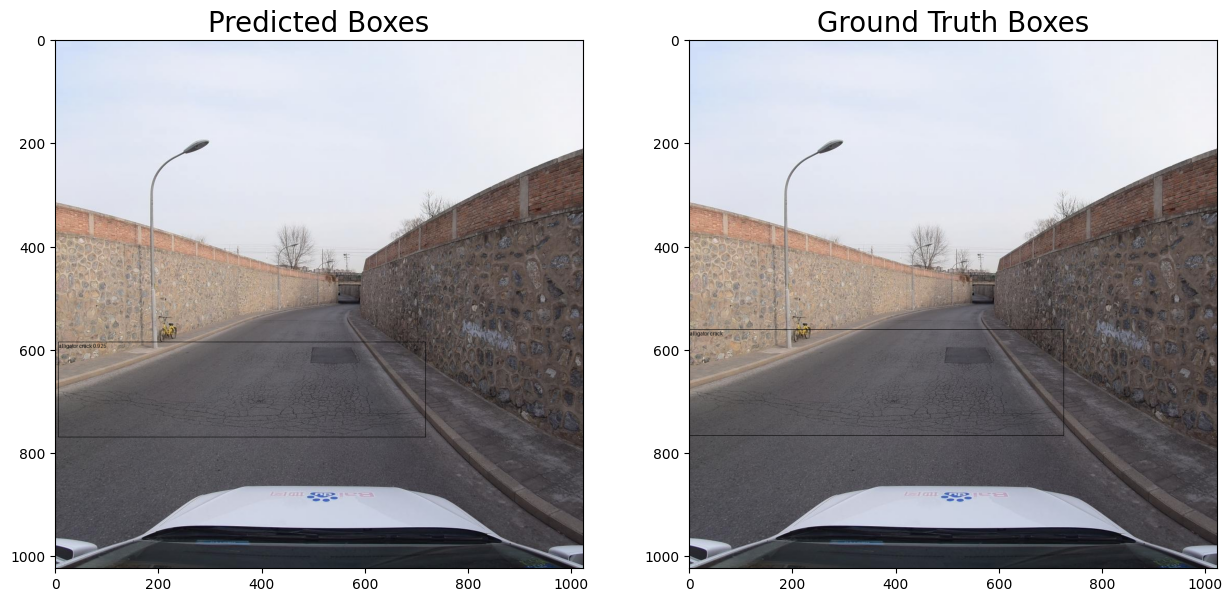

In [23]:
# Example Prediction
image_id = 500
threshold = 0.25

with open(json_detection_path) as f:
    all_preds = json.load(f)
    
print("Getting one example prediction...")
pred_box, pred_label, pred_score = get_one_example_prediction(image_id, all_preds)

# Adjust to best threshold
keep = pred_score >= threshold
boxes = pred_box[keep]
labels = pred_label[keep]
scores = pred_score[keep]

# Convert boxes from COCO format [x, y, w, h] to xyxy [xmin, ymin, xmax, ymax]
boxes[:, 2] = boxes[:, 0] + boxes[:, 2]
boxes[:, 3] = boxes[:, 1] + boxes[:, 3]

# Getting image and annotation target
img_tensor, target = get_image_and_target(image_id, EVALUATE_DIRECTORY)

print("Visualizing Prediction...")
# Visualize predictions.
image_with_boxes = utils.draw_bounding_boxes(
    image=(img_tensor * 255).to(torch.uint8),
    boxes=boxes,
    labels=[f"{CLASSES[label.item()]} {score:.3f}" for label, score in zip(labels, scores)],
)

fig, ax = plt.subplots(1, 2, figsize=(15, 15))
ax[0].imshow(image_with_boxes.permute(1, 2, 0))

print("Visualizing GroundTruth...")
# Visualize predictions.
image_with_boxes = utils.draw_bounding_boxes(
    image=(img_tensor * 255).to(torch.uint8),
    boxes=target["boxes"],
    labels=[f"{CLASSES[label.item()]}" for label in target["labels"]],
)

# Colocar título nas imagens
ax[0].set_title("Predicted Boxes", fontsize=20)
ax[1].set_title("Ground Truth Boxes", fontsize=20)
ax[1].imshow(image_with_boxes.permute(1, 2, 0))
plt.show()